### Data

In [48]:
kal = True
oov_types = False
book_only = True

if kal:
    eng = False
else:
    eng = True

import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from adjustText import adjust_text


In [49]:
# eng-kal data

# x = np.array([395, 94, 94, 62, 57, 41, 164, 127, 91, 125, 133, 117, 121, 87, 69, 62, 395])
# y = np.array([12.7, 34.7, 38.5, 46.6, 39.8, 47.5, 27.9, 33.1, 34.4, 27.8, 27.5, 34.7, 33.7, 30, 38.3, 44.9, 13.9])

if oov_types:
    if eng:
        x = np.array([395, 94, 94, 62, 57, 41, 164, 127, 91, 125, 133, 117, 121, 87, 69, 62, 395, 46])
        y = np.array([12.7, 34.7, 38.5, 46.6, 39.8, 47.5, 27.9, 33.1, 34.4, 27.8, 27.5, 34.7, 33.7, 45.8, 38.3, 44.9, 13.9, 46.1])
        labels = ["0-shot", "5-shot", r"$P_{book} + P_{train}$", r"$P_{book} + P_{train} + W$", r"$P_{full}$", r"$P_{full} + W$", "W",
        r"$P_{book}$", r"$Book_{all}$", r"$\mathrm{Book}_{\neg p}$", r"$\mathrm{Book}_{\neg p*}$", r"$\mathrm{Book}_{p*}$", r"$\mathrm{Book}_{p}$",
        r"$P_{book} + W$", r"$Book_{all} + W$", r"$Typ + W + P_{book} + P_{train}$", "Typ 0-shot", r"$Book_{all} + P_{train} + W$"]


    # kal-eng data
    if kal:
        x = np.array([374, 156, 156, 93, 122, 73, 171, 201, 203, 243, 256, 219, 226, 124, 142, 93, 374, 106])
        y = np.array([11, 38.7, 33.4, 40.7, 35.6, 41.3, 29.1, 26.6, 34.4, 23.8, 22.6, 30.8, 30.7, 34.7, 39.6, 40.6, 10.8, 43.7])
        labels = ["0-shot", "5-shot", r"$P_{book} + P_{train}$", r"$P_{book} + P_{train} + W$", r"$P_{full}$", r"$P_{full} + W$", "W",
        r"$P_{book}$", r"$Book_{all}$", r"$\mathrm{Book}_{\neg p}$", r"$\mathrm{Book}_{\neg p*}$", r"$\mathrm{Book}_{p*}$", r"$\mathrm{Book}_{p}$",
        r"$P_{book} + W$", r"$Book_{all} + W$", r"$Typ + W + P_{book} + P_{train}$", "Typ 0-shot", r"$Book_{all} + P_{train} + W$"]
        # labels = ["0-shot", "5-shot", "Extra Parallel", "Extra + Wordlist", "Full Parallel", "Full +Wordlist", "Wordlist",
        # "Extra only", "Full book", "Book non-parallel", "Book non-parallel/pairs", "Book parallel+pairs", "Book parallel",
        # "Extra only + Wordlist", "Book + Wordlist", "Typology + Wordlist + Book Parallel", "0-shot Typology"]

elif not oov_types:
    if eng:
        x = np.array([0, 2825, 12121, 17058, 24096, 29033, 4937, 9296, 99579, 81270, 81270, 18309, 16264, 14239, 104054, 17058, 0, 106879])
        y = np.array([12.7, 34.7, 38.5, 46.6, 39.8, 47.5, 27.9, 33.1, 34.4, 27.8, 27.5, 34.7, 33.7, 45.8, 38.3, 44.9, 13.9, 46.1])
        labels = ["0-shot", "5-shot", r"$P_{book} + P_{train}$", r"$P_{book} + P_{train} + W$", r"$P_{full}$", r"$P_{full} + W$", "W",
        r"$P_{book}$", r"$Book_{all}$", r"$\mathrm{Book}_{\neg p}$", r"$\mathrm{Book}_{\neg p*}$", r"$\mathrm{Book}_{p*}$", r"$\mathrm{Book}_{p}$",
        r"$P_{book} + W$", r"$Book_{all} + W$", r"$Typ + W + P_{book} + P_{train}$", "Typ 0-shot", r"$Book_{all} + P_{train} + W$"]



    # kal-eng data
    if kal:
        x = np.array([0, 2010, 8263, 12337, 17060, 21134, 4074, 6253, 99579, 81270, 81270, 18309, 16264, 10333, 103191, 12337, 0, 105201])
        y = np.array([11, 38.7, 33.4, 40.7, 35.6, 41.3, 29.1, 26.6, 34.4, 23.8, 22.6, 30.8, 30.7, 34.7, 39.6, 40.6, 10.8, 43.7])
        labels = ["0-shot", "5-shot", r"$P_{book} + P_{train}$", r"$P_{book} + P_{train} + W$", r"$P_{full}$", r"$P_{full} + W$", "W",
        r"$P_{book}$", r"$Book_{all}$", r"$\mathrm{Book}_{\neg p}$", r"$\mathrm{Book}_{\neg p*}$", r"$\mathrm{Book}_{p*}$", r"$\mathrm{Book}_{p}$",
        r"$P_{book} + W$", r"$Book_{all} + W$", r"$Typ + W + P_{book} + P_{train}$", "Typ 0-shot", r"$Book_{all} + P_{train} + W$"]

if book_only:  #8-13
    x = np.concatenate(([x[8]], x[10:12]))
    y = np.concatenate(([y[8]], y[10:12]))
    labels = np.concatenate(([labels[8]], labels[10:12]))

print(y)

[34.4 22.6 30.8]


### Fit regression model

In [50]:


print("\nResiduals significance test")

# data same as above

# Add a constant to X for the intercept term
X = sm.add_constant(x)

# Fit the regression model
model = sm.OLS(y, X).fit()
predictions = model.predict(X)
print(model.summary())


Residuals significance test
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -1.000
Method:                 Least Squares   F-statistic:                 2.454e-05
Date:                Tue, 06 Aug 2024   Prob (F-statistic):              0.997
Time:                        14:58:11   Log-Likelihood:                -9.0476
No. Observations:                   3   AIC:                             22.10
Df Residuals:                       1   BIC:                             20.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.3133  

/home/saycock/miniconda3/envs/cuda11/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### Plot results

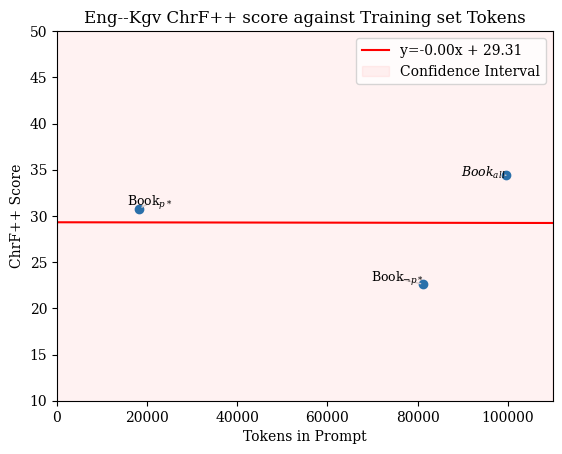

In [51]:

# labels = [
# "0-shot", "5-shot", "Extra Parallel", "Extra + Wordlist", "Full Parallel", "Full + Wordlist", "Wordlist",
# "Extra only", "Full book", "Book non-parallel", "Book non-parallel/pairs", "Book parallel+pairs", "Book parallel"
# ]

# labels = [
# "0-shot", "5-shot", "Extra Parallel", "", "", "", "Wordlist",
# "", "Full book", "", "Book non-parallel/pairs", "Book parallel+pairs", ""
# ]

plt.scatter(x, y)
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

if oov_types:
    plt.gca().invert_xaxis()

texts = []
# for i, label in enumerate(labels):
#     plt.annotate(label, (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

texts = [plt.text(x[i], y[i], labels[i], ha='right', va='bottom', fontsize=9) for i in range(len(labels))]
adjust_text(texts, expand=(1.3, 2), arrowprops=dict(arrowstyle='-', color='lightgray'))

# plot linear regression model
# plt.plot(x, predictions, color='red', label='Regression Line')

if oov_types:
    x_min, x_max = 400, 0 
    y_min, y_max = 10, 50 
else:
    x_min, x_max = 0, 110000 
    y_min, y_max = 10, 50

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
x_extended = np.linspace(x_min, x_max, 100)
X_extended = sm.add_constant(x_extended)
# plot linear regression model to axis limits
predictions_extended = model.predict(X_extended)

# 
plt.plot(x_extended, predictions_extended, color='red', label=f'y={model.params[1]:.2f}x + {model.params[0]:.2f}')

from statsmodels.sandbox.regression.predstd import wls_prediction_std
predictions_extended, lower_extended, upper_extended = wls_prediction_std(model, exog=X_extended)
# plt.fill_between(x, lower, upper, color='pink', alpha=0.3, label='Confidence Interval')
plt.fill_between(x_extended, lower_extended, upper_extended, color='red', alpha=0.05, label='Confidence Interval')

    
if kal:
    direction = "Eng--Kgv"
elif eng:
    direction = "Kgv--Eng"

# Display the plot

plt.ylabel('ChrF++ Score')
if oov_types:
    plt.xlabel('OOV Test Set words in Prompt')
    plt.title(f'{direction} ChrF++ score against OOV Test set Types')
else:
    plt.xlabel('Tokens in Prompt')
    plt.title(f'{direction} ChrF++ score against Training set Tokens')
plt.legend()
plt.show()

In [52]:

print("Pearson's correlation test")

# Calculate Pearson's correlation coefficient
r, _ = stats.pearsonr(x, y)

# Formulate hypotheses
# H0: There is no correlation (rho = 0)
# H1: There is a positive correlation (rho > 0)

# Calculate the test statistic
n = len(x)  # Number of data points
t_stat = r * np.sqrt((n - 2) / (1 - r**2))

# Determine the critical value and p-value
alpha = 0.05  # Significance level
t_critical = stats.t.ppf(1 - alpha, n - 2)
p_value = stats.t.cdf(t_stat, df=n - 2)

# Decision rule
if oov_types:
    is_significant = t_stat < t_critical
else:
    is_significant = t_stat > t_critical\

# Print the results
print(f"Pearson's correlation coefficient: {r}")
print(f"t-statistic: {t_stat}")
print(f"Critical t-value: {t_critical}")
print(f"p-value: {p_value}")
print(f"Is there a significant positive correlation? {'Yes' if is_significant else 'No'}")


Pearson's correlation test
Pearson's correlation coefficient: -0.0049532350928284865
t-statistic: -0.004953295856613616
Critical t-value: 6.313751514800932
p-value: 0.4984233298541698
Is there a significant positive correlation? No
